<a href="https://colab.research.google.com/github/Orzilber/computationl-statistics/blob/collab/Gibbs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

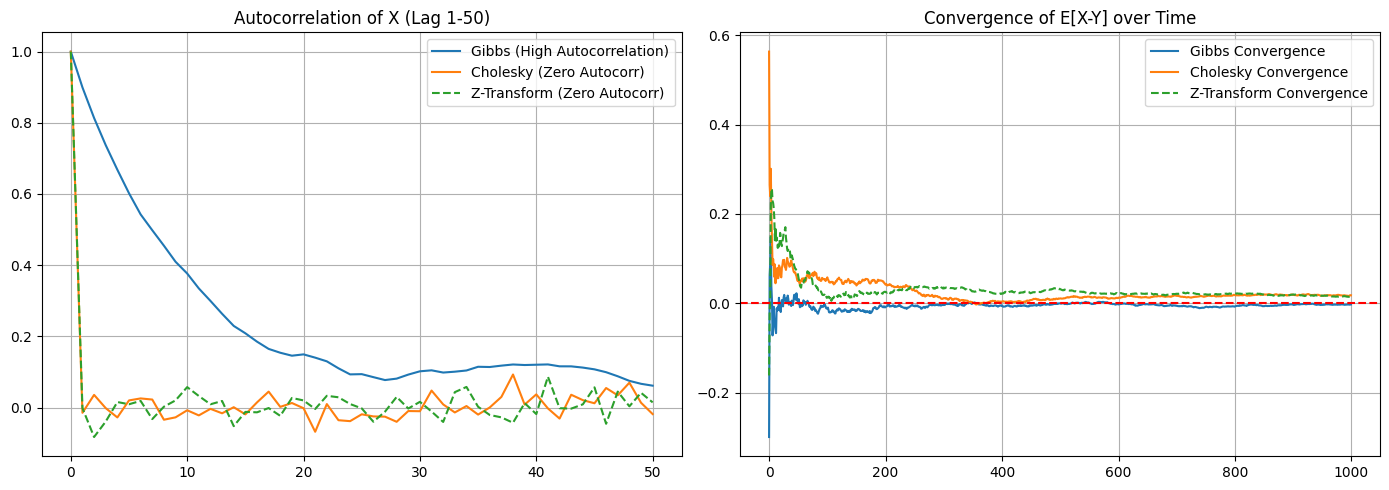

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

rho = 0.95
n_samples = 1000
mu = np.array([0, 0])
cov = np.array([[1, rho], [rho, 1]])

# 1. Cholesky Decomposition (Direct Independent Sampling)
L = np.linalg.cholesky(cov)
z = np.random.randn(2, n_samples)
samples_chol = (L @ z).T

# 2. Z-Transformation Method (User's proposed decorrelation)
var_z1 = 2 * (1 + rho)
var_z2 = 2 * (1 - rho)
z1 = np.random.normal(0, np.sqrt(var_z1), n_samples)
z2 = np.random.normal(0, np.sqrt(var_z2), n_samples)
x_z = (z1 + z2) / 2
y_z = (z1 - z2) / 2
samples_z = np.stack([x_z, y_z], axis=1)

# 3. Gibbs Sampler
samples_gibbs = np.zeros((n_samples, 2))
curr_x, curr_y = 0, 0
for i in range(n_samples):
    curr_x = np.random.normal(rho * curr_y, np.sqrt(1 - rho**2))
    curr_y = np.random.normal(rho * curr_x, np.sqrt(1 - rho**2))
    samples_gibbs[i] = [curr_x, curr_y]

# 4. Analysis: E[X-Y] convergence
diff_gibbs = np.cumsum(samples_gibbs[:, 0] - samples_gibbs[:, 1]) / np.arange(1, n_samples + 1)
diff_chol = np.cumsum(samples_chol[:, 0] - samples_chol[:, 1]) / np.arange(1, n_samples + 1)
diff_z = np.cumsum(samples_z[:, 0] - samples_z[:, 1]) / np.arange(1, n_samples + 1)

# 5. Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Autocorrelation (Comparison of mixing speeds)
ax[0].plot(acf(samples_gibbs[:, 0], nlags=50), label='Gibbs (High Autocorrelation)')
ax[0].plot(acf(samples_chol[:, 0], nlags=50), label='Cholesky (Zero Autocorr)')
ax[0].plot(acf(samples_z[:, 0], nlags=50), label='Z-Transform (Zero Autocorr)', linestyle='--')
ax[0].set_title('Autocorrelation of X (Lag 1-50)')
ax[0].legend()
ax[0].grid(True)

# Convergence Comparison
ax[1].plot(diff_gibbs, label='Gibbs Convergence')
ax[1].plot(diff_chol, label='Cholesky Convergence')
ax[1].plot(diff_z, label='Z-Transform Convergence', linestyle='--')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('Convergence of E[X-Y] over Time')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()